In [1]:
try:
    import os
    import json
    import torchvision.transforms as transforms
    import numpy as np
    import cv2
    import torch
    import torchvision
    import matplotlib.pyplot as plt
    from PIL import Image
    from ultralytics import YOLO
    from torch.utils.data import Dataset, DataLoader
    from torchvision.models.detection import (
        fasterrcnn_resnet50_fpn_v2,
        FasterRCNN_ResNet50_FPN_V2_Weights
    )
    import random
    import pycocotools.coco as coco
    from pycocotools.coco import COCO
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from pycocotools.cocoeval import COCOeval
    import os
    import requests
    import json
    import time
    import xml.etree.ElementTree as ET
except:
    %pip install opencv-python ultralytics torch torchvision pycocotools matplotlib numpy
    import os
    import json
    import requests
    import random
    import time
    import numpy as np
    import cv2
    import torch
    import torchvision.transforms as transforms
    import torchvision
    import matplotlib.pyplot as plt
    from PIL import Image
    from ultralytics import YOLO
    from torch.utils.data import Dataset, DataLoader
    from torchvision.models.detection import (
        fasterrcnn_resnet50_fpn_v2,
        FasterRCNN_ResNet50_FPN_V2_Weights
    )
    import pycocotools.coco as coco
    from pycocotools.coco import COCO
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from pycocotools.cocoeval import COCOeval
    import xml.etree.ElementTree as ET

## Декодирование видео в последовательность кадров -> Видео успешно сегментировано. Было извлечен 301 кадр.


In [2]:
INPUT_VIDEO = "input.mp4"
OUTPUT_VIDEO = "output.mp4"
XML_ANNOTATIONS = "annotations.xml"
FRAMES_DIR = "frames_data"
TRAIN_JSON = "train_coco.json"
VAL_JSON = "val_coco.json"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STEP = 1

def extract_frames(video_path, out_dir, step=5):
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    frame_paths, idx = [], 0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            p = os.path.join(out_dir, f"frame_{idx:05d}.jpg")
            cv2.imwrite(p, frame)
            frame_paths.append(p)
        idx += 1
    cap.release()
    return frame_paths, w, h


print("1. Извлечение кадров")
frames, width, height = extract_frames(INPUT_VIDEO, FRAMES_DIR, step=STEP)
print(f"Извлечено: {len(frames)} кадров. Разрешение: {width}x{height}")

1. Извлечение кадров
Извлечено: 301 кадров. Разрешение: 1920x1080


### Сравнительный анализ методов распознавания разметки. Использован CV-API, визуальный метод (OpenCV), оценка качества по IoU.

### Функция парсинга изх annotations.xml

In [3]:
def parse_xml_to_dict(xml_path, frame_paths):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    gt_data = {i+1: [] for i in range(len(frame_paths))}

    for track in root.findall('.//track'):
        for box in track.findall('box'):
            if box.get('outside') == '1':
                continue
            f_num = int(box.get('frame'))
            if f_num % STEP == 0:
                idx = (f_num // STEP) + 1
                if idx in gt_data:
                    xtl, ytl = float(box.get('xtl')), float(box.get('ytl'))
                    xbr, ybr = float(box.get('xbr')), float(box.get('ybr'))
                    gt_data[idx].append([xtl, ytl, xbr-xtl, ybr-ytl])
    return gt_data


print("2. Загрузка эталона из XML")
original_gt = parse_xml_to_dict(XML_ANNOTATIONS, frames)

2. Загрузка эталона из XML


### Обе функции реализуют извлечение пространственной разметки объектов из видео, но разными способами: `get_yolo_annotations` использует детектор `YOLOv8n` для поиска объектов на сохранённых кадрах, а `get_visual_annotations` - классическую цветовую сегментацию зелёных областей в HSV с фильтрацией мелких контуров.

In [4]:
def get_yolo_annotations(frame_paths):
    model = YOLO("yolov8n.pt")
    results = []
    for p in frame_paths:
        res = model(p, verbose=False)[0]
        boxes = [b.xyxy[0].tolist() for b in res.boxes]
        results.append([[b[0], b[1], b[2]-b[0], b[3]-b[1]] for b in boxes])
    return results


def get_visual_annotations(video_path, step=5):
    cap = cv2.VideoCapture(video_path)
    results, idx = [], 0
    lower_green = np.array([35, 100, 100])
    upper_green = np.array([85, 255, 255])
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            mask = cv2.inRange(hsv, lower_green, upper_green)
            cnts, _ = cv2.findContours(
                mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            results.append([[float(x), float(y), float(w), float(h)]
                            for x, y, w, h in [cv2.boundingRect(c) for c in cnts] if w*h > 200])
        idx += 1
    cap.release()
    return results


print("3. Извлечение разметки (API и Визуальный метод)")
yolo_stolen = get_yolo_annotations(frames)
visual_stolen = get_visual_annotations(OUTPUT_VIDEO, step=STEP)

3. Извлечение разметки (API и Визуальный метод)


### Автоматическая генерация разметки кадра с помощью модели DETR через Hugging Face Inference API.

In [ ]:
HF_TOKEN = ""
API_URL = "https://router.huggingface.co/hf-inference/models/facebook/detr-resnet-50"
headers = {"Authorization": f"Bearer {HF_TOKEN}", "Content-Type": "image/jpeg"}
output_file = "hf_annotations.json"
hf_results = {}

print(f"Обработка {len(frames)} кадров...")

for i, img_path in enumerate(frames):
    frame_name = os.path.basename(img_path)
    with open(img_path, "rb") as f:
        data = f.read()

    response = requests.post(API_URL, headers=headers, data=data)

    if response.status_code == 200:
        raw_data = response.json()
        target_labels = {'car', 'truck', 'bus', 'van', 'motorcycle'}
        frame_boxes = []
        for item in raw_data:
            label = item.get('label', '').lower()
            if any(x in label for x in target_labels) and item.get('score', 0) >= 0.3:
                b = item['box']
                frame_boxes.append({
                    "box": [float(b['xmin']), float(b['ymin']), float(b['xmax']), float(b['ymax'])],
                    "score": item['score'],
                    "label": 'car'
                })
        hf_results[frame_name] = frame_boxes
    else:
        hf_results[frame_name] = []
        print(f"Ошибка на {frame_name}: {response.status_code}")

    time.sleep(0.5)
    if (i + 1) % 10 == 0:
        print(f"Обработано {i + 1} кадров")

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(hf_results, f, indent=4, ensure_ascii=False)

print("Готово!")

Обработка 301 кадров...
Обработано 10 кадров
Обработано 20 кадров
Обработано 30 кадров
Обработано 40 кадров
Обработано 50 кадров
Обработано 60 кадров
Обработано 70 кадров
Обработано 80 кадров
Обработано 90 кадров
Обработано 100 кадров
Обработано 110 кадров
Обработано 120 кадров
Обработано 130 кадров
Обработано 140 кадров
Обработано 150 кадров
Обработано 160 кадров
Обработано 170 кадров
Обработано 180 кадров
Обработано 190 кадров
Обработано 200 кадров
Обработано 210 кадров
Обработано 220 кадров
Обработано 230 кадров
Обработано 240 кадров
Обработано 250 кадров
Обработано 260 кадров
Обработано 270 кадров
Обработано 280 кадров
Обработано 290 кадров
Обработано 300 кадров
Готово!


In [ ]:
hf_stolen = []
if os.path.exists("hf_annotations.json"):
    with open("hf_annotations.json", "r", encoding="utf-8") as f:
        hf_results = json.load(f)

    for img_path in frames:
        frame_name = os.path.basename(img_path)
        hf_preds = hf_results.get(frame_name, [])
        frame_boxes = []
        for item in hf_preds:
            xmin, ymin, xmax, ymax = item['box']
            frame_boxes.append([xmin, ymin, xmax - xmin, ymax - ymin])
        hf_stolen.append(frame_boxes)
else:
    print("ВНИМАНИЕ: Файл hf_annotations.json не найден.")
    hf_stolen = [[] for _ in frames]

## Оценка качества

### Hugging Face API (DETR) продемонстрировал наилучшую точность (IoU 0.748), значительно превзойдя остальных. YOLOv8 оказался посередине, а визуальный метод OpenCV — наихудшим.



In [ ]:
def calculate_iou(b1, b2):
    ix1, iy1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    ix2, iy2 = min(b1[0]+b1[2], b2[0]+b2[2]), min(b1[1]+b1[3], b2[1]+b2[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    union = b1[2]*b1[3] + b2[2]*b2[3] - inter
    return inter / union if union > 0 else 0


def evaluate_iou_score(gt_dict, stolen_list):
    all_ious = []
    for i, stolen_boxes in enumerate(stolen_list):
        gt_boxes = gt_dict.get(i+1, [])
        for gb in gt_boxes:
            best_iou = max([calculate_iou(gb, sb)
                           for sb in stolen_boxes] + [0])
            all_ious.append(best_iou)
    return np.mean(all_ious) if all_ious else 0


iou_yolo = evaluate_iou_score(original_gt, yolo_stolen)
iou_visual = evaluate_iou_score(original_gt, visual_stolen)
iou_hf = evaluate_iou_score(original_gt, hf_stolen)
print(f"1. YOLOv8 (Локально) = {iou_yolo:.3f}")
print(f"2. Hugging Face API (DETR) = {iou_hf:.3f}")
print(f"3. OpenCV (Цветовой фильтр) = {iou_visual:.3f}")

1. YOLOv8 (Локально) = 0.564
2. Hugging Face API (DETR) = 0.748
3. OpenCV (Цветовой фильтр) = 0.090


## Формирование датасета в формате COCO, разделение на train/val

### Формирование аннотаций в формате COCO: создаётся словарь с изображениями и bounding box'ами, каждому кадру присваивается id, а все найденные объекты записываются как автомобили категории 1.

In [7]:
coco_final = {"images": [], "annotations": [],
              "categories": [{"id": 1, "name": "car"}]}
ann_id = 1
for i, (path, boxes) in enumerate(zip(frames, yolo_stolen)):
    img_id = i + 1
    coco_final["images"].append({"id": img_id, "file_name": os.path.basename(
        path), "width": width, "height": height})
    for b in boxes:
        coco_final["annotations"].append({
            "id": ann_id, "image_id": img_id, "bbox": b, "area": b[2]*b[3], "category_id": 1, "iscrowd": 0
        })
        ann_id += 1

## Случайное разделение COCO-датасета на обучающую (80%) и валидационную (20%) выборки по image_id с последующим сохранением в JSON-файлы.

In [8]:
def save_coco_format(data, path):
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

ids = [img['id'] for img in coco_final['images']]
random.shuffle(ids)
train_ids = set(ids[:int(0.8*len(ids))])

train_coco = {
    "images": [img for img in coco_final['images'] if img['id'] in train_ids],
    "annotations": [ann for ann in coco_final['annotations'] if ann['image_id'] in train_ids],
    "categories": coco_final["categories"]
}
val_coco = {
    "images": [img for img in coco_final['images'] if img['id'] not in train_ids],
    "annotations": [ann for ann in coco_final['annotations'] if ann['image_id'] not in train_ids],
    "categories": coco_final["categories"]
}
save_coco_format(train_coco, TRAIN_JSON)
save_coco_format(val_coco, VAL_JSON)


## Обучение модели. Обучение Faster R-CNN и контроль переобучения

### Класс-датасет PyTorch, который загружает COCO-разметку из JSON, читает соответствующие изображения из директории и возвращает тензор кадра вместе с целевыми bounding box'ами (в формате x1,y1,x2,y2) и метками

In [9]:
class LabDataset(Dataset):
    def __init__(self, json_path, img_dir, transforms=None):
        self.coco = COCO(json_path)
        self.ids = list(self.coco.imgs.keys())
        self.img_dir = img_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        path = os.path.join(self.img_dir, self.coco.loadImgs(img_id)[0]['file_name'])
        img = Image.open(path).convert("RGB")

        if self.transforms is not None:
            img = self.transforms(img)

        img = torchvision.transforms.functional.to_tensor(img)

        boxes = torch.as_tensor([a['bbox'] for a in anns], dtype=torch.float32)
        if len(boxes) > 0:
            boxes[:, 2:] += boxes[:, :2]
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)

        target = {
            "boxes": boxes,
            "labels": torch.ones((len(boxes),), dtype=torch.int64),
            "image_id": torch.tensor([img_id])
        }
        return img, target

### Функции обучения и валидации Faster R-CNN: train_one_epoch выполняет прямой проход с вычислением multi-task лосса, обратное распространение и шаг оптимизатора, возвращая средний лосс за эпоху, а validate_loss в режиме torch.`no_grad()` вычисляет чистый лосс на валидационной выборке без обновления весов.



In [10]:
def train_one_epoch(model, optimizer, loader, device):
    model.train()
    total_loss = 0
    for imgs, targets in loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        total_loss += losses.item()
    return total_loss / len(loader)


def validate_loss(model, loader, device):
    model.train()
    val_loss = 0
    with torch.no_grad():
        for imgs, targets in loader:
            imgs = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()}
                       for t in targets]
            loss_dict = model(imgs, targets)
            val_loss += sum(loss for loss in loss_dict.values()).item()
        return val_loss / len(loader)

### Обучение Faster R-CNN с ResNet-50 FPN V2 на двух классах (фон + автомобиль). Модель дообучается 20 эпох с косинусным планировщиком LR, ранней остановкой по валидационному лоссу (patience=5) и сохранением лучших весов. В конце строится график Train/Val Loss.

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 190MB/s]


Начинаем обучение...
Эпоха 01/20: Loss Train=0.3546, Loss Val=0.2577, LR=0.004969
Эпоха 02/20: Loss Train=0.2026, Loss Val=0.2220, LR=0.004878
Эпоха 03/20: Loss Train=0.1810, Loss Val=0.2226, LR=0.004728
Эпоха 04/20: Loss Train=0.1620, Loss Val=0.2074, LR=0.004523
Эпоха 05/20: Loss Train=0.1445, Loss Val=0.1961, LR=0.004269
Эпоха 06/20: Loss Train=0.1329, Loss Val=0.2194, LR=0.003972
Эпоха 07/20: Loss Train=0.1209, Loss Val=0.1969, LR=0.003638
Эпоха 08/20: Loss Train=0.1099, Loss Val=0.2088, LR=0.003276
Эпоха 09/20: Loss Train=0.0999, Loss Val=0.1958, LR=0.002895
Эпоха 10/20: Loss Train=0.0926, Loss Val=0.1921, LR=0.002505
Эпоха 11/20: Loss Train=0.0845, Loss Val=0.1982, LR=0.002115
Эпоха 12/20: Loss Train=0.0763, Loss Val=0.1967, LR=0.001734
Эпоха 13/20: Loss Train=0.0714, Loss Val=0.2027, LR=0.001372
Эпоха 14/20: Loss Train=0.0657, Loss Val=0.1959, LR=0.001038
Эпоха 15/20: Loss Train=0.0610, Loss Val=0.2024, LR=0.000741
Ранняя остановка на эпохе 15: лосс на валидации перестал падать.

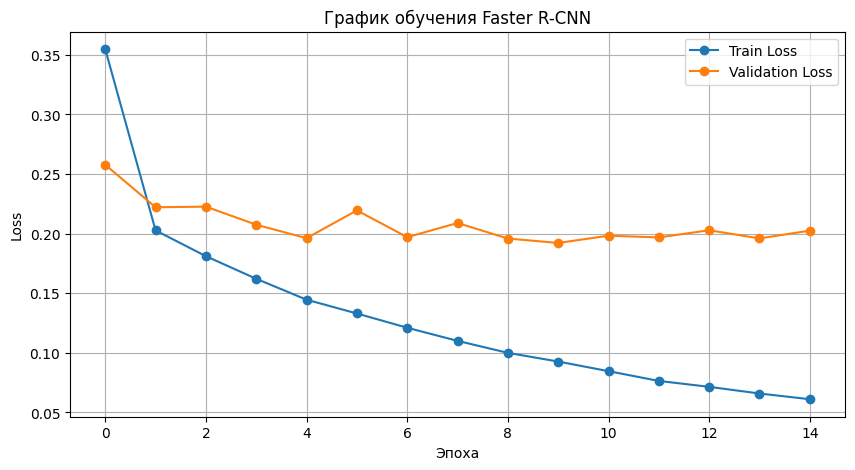

In [11]:
train_transforms = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

train_ds = LabDataset(TRAIN_JSON, FRAMES_DIR, transforms=train_transforms)
val_ds = LabDataset(VAL_JSON, FRAMES_DIR, transforms=None)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True,
                          collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False,
                        collate_fn=lambda x: tuple(zip(*x)))


model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)
in_f = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_f, 2)
model.to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)


train_hist, val_hist = [], []
best_val_loss = float('inf')
patience = 5
counter = 0
num_epochs = 20

print("Начинаем обучение...")
for epoch in range(num_epochs):
    t_loss = train_one_epoch(model, optimizer, train_loader, DEVICE)
    v_loss = validate_loss(model, val_loader, DEVICE)


    lr_scheduler.step()

    train_hist.append(t_loss)
    val_hist.append(v_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Эпоха {epoch+1:02d}/{num_epochs}: Loss Train={t_loss:.4f}, Loss Val={v_loss:.4f}, LR={current_lr:.6f}")

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Ранняя остановка на эпохе {epoch+1}: лосс на валидации перестал падать.")
            break


plt.figure(figsize=(10, 5))
plt.plot(train_hist, label='Train Loss', marker='o')
plt.plot(val_hist, label='Validation Loss', marker='o')
plt.title('График обучения Faster R-CNN')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

## Оценка качества (mAP) и визуализация

### Модель демонстрирует высокую точность детекции (mAP 0.800, AP@0.50 = 0.900), особенно на средних объектах (AP 0.838). Полнота (Recall) достигает 0.841 при 100 предсказаниях на кадр, что говорит о способности находить подавляющее большинство автомобилей. При этом низкий AR@1 (0.091) указывает на избыточность предсказаний — модель выдаёт несколько боксов на один объект.

In [12]:
def compute_map(model, dataset):
    model.eval()
    results = []
    with torch.no_grad():
        for i in range(len(dataset)):
            img, target = dataset[i]
            img_id = target['image_id'].item()
            pred = model([img.to(DEVICE)])[0]
            for box, score, label in zip(pred['boxes'], pred['scores'], pred['labels']):
                b = box.cpu().tolist()
                results.append({
                    "image_id": img_id, "category_id": int(label),
                    "bbox": [b[0], b[1], b[2]-b[0], b[3]-b[1]], "score": float(score)
                })
    if not results:
        return 0
    coco_dt = dataset.coco.loadRes(results)
    evaluator = COCOeval(dataset.coco, coco_dt, 'bbox')
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()
    return evaluator.stats[0]


print("7. Итоговые метрики")
mAP = compute_map(model, val_ds)
print(f"Итоговый mAP: {mAP:.3f}")


7. Итоговые метрики
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.15s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.800
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.900
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.887
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.673
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.838
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.736
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.091
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.777
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.841
 Average Recall     (AR) @[ IoU=0.50:0.95 | area

In [ ]:
def draw_complete_video(model, output_name, json_path, conf_threshold=0.5, iou_threshold=0.3):
    check_ds = LabDataset(json_path, FRAMES_DIR, transforms=None)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_name, fourcc, 5.0, (width, height))

    model.eval()
    print(f"Начинается сборка видео: {output_name}...")

    with torch.no_grad():
        for i in range(len(check_ds)):
            img, _ = check_ds[i]
            pred = model([img.to(DEVICE)])[0]

            img_cv = cv2.cvtColor((img.permute(1, 2, 0).numpy() * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

            boxes = pred['boxes']
            scores = pred['scores']


            keep = torchvision.ops.nms(boxes, scores, iou_threshold)

            final_boxes = boxes[keep]
            final_scores = scores[keep]

            for box, score in zip(final_boxes, final_scores):
                if score > conf_threshold:
                    b = box.int().cpu().numpy()
                    cv2.rectangle(img_cv, (b[0], b[1]), (b[2], b[3]), (0, 255, 0), 3)
                    cv2.putText(img_cv, f"{score:.2f}", (b[0], b[1]-10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            out.write(img_cv)

    out.release()
    print(f"Видео {output_name} готово и сохранено!")


if os.path.exists("best_model.pth"):
    print("Загружаем веса лучшей модели (best_model.pth) для инференса...")
    model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))

draw_complete_video(model, "val_inference_check.mp4", VAL_JSON, conf_threshold=0.4, iou_threshold=0.5)

with open("temp_all.json", "w") as f:
    json.dump(coco_final, f)

draw_complete_video(model, "full_result.mp4", "temp_all.json", conf_threshold=0.4, iou_threshold=0.5)
print("Все финальные видео успешно сгенерированы!")

Загружаем веса лучшей модели (best_model.pth) для инференса...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Начинается сборка видео: val_inference_check.mp4...
Видео val_inference_check.mp4 готово и сохранено!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Начинается сборка видео: full_result.mp4...
Видео full_result.mp4 готово и сохранено!
Все финальные видео успешно сгенерированы!


### Визуальный анализ качества детекции - модель разбивает предсказания на две группы: успешные (confidence > 0.75, зелёные рамки) и ложные срабатывания (confidence 0.12–0.45, синие рамки).

Загружены лучшие веса модели.
Разделяем детекции на успешные и ложные...


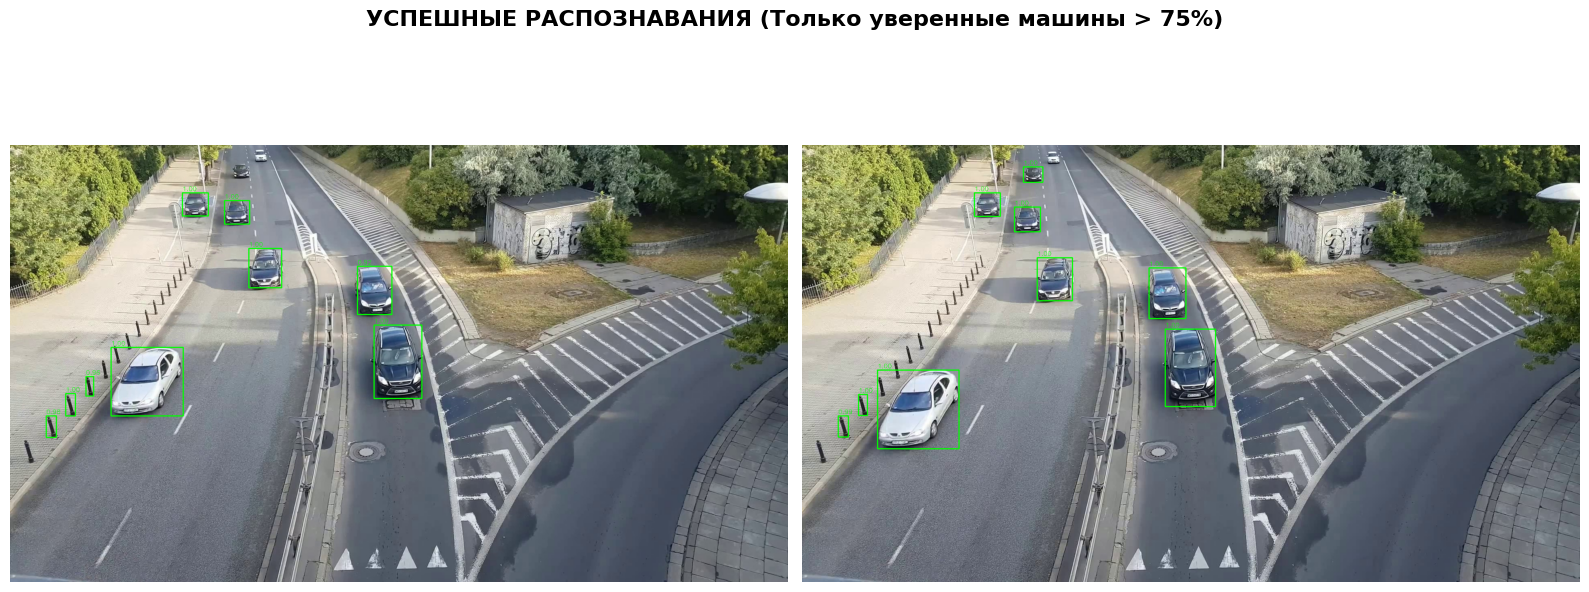

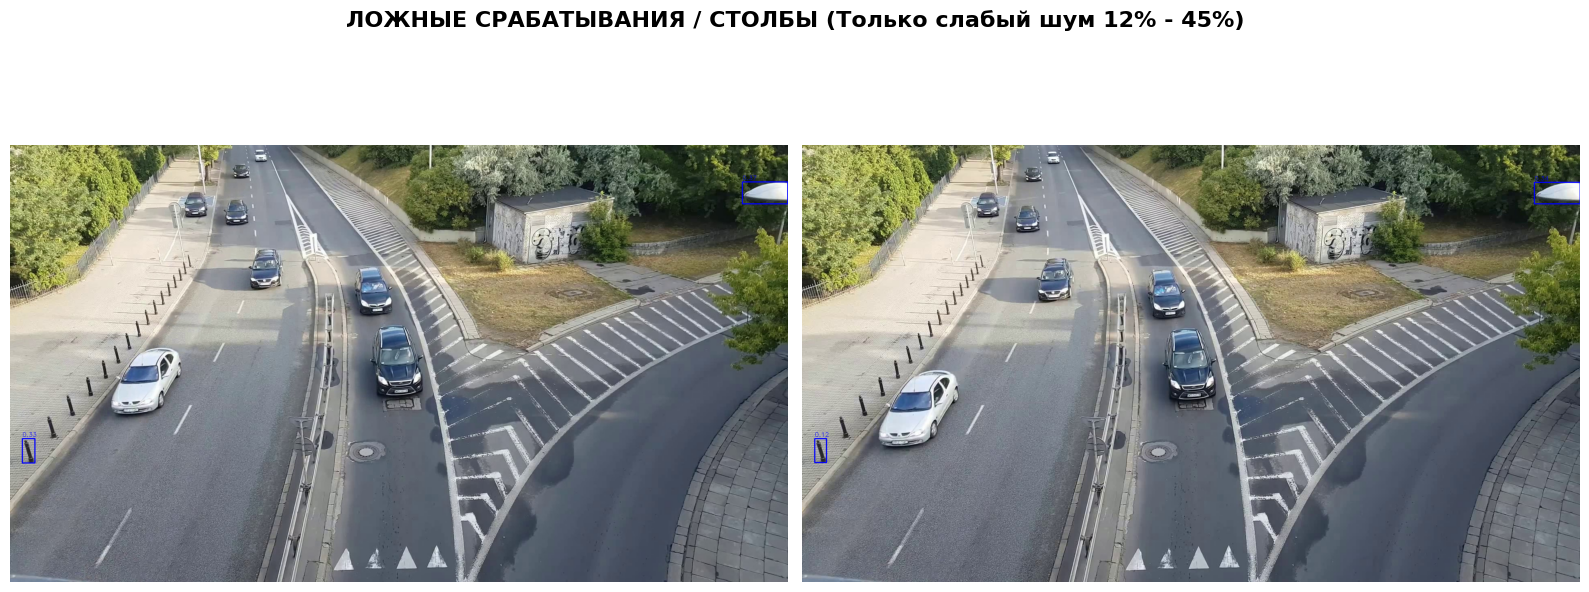

In [ ]:
if os.path.exists("best_model.pth"):
    model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
    print("Загружены лучшие веса модели.")

model.roi_heads.score_thresh = 0.05
model.eval()

success_examples = []
error_examples = []

print("Разделяем детекции на успешные и ложные...")
with torch.no_grad():
    for i in range(len(val_ds)):
        if len(success_examples) >= 2 and len(error_examples) >= 2:
            break

        img, target = val_ds[i]
        outputs = model([img.to(DEVICE)])[0]

        img_np = (img.permute(1, 2, 0).cpu().numpy() * 255).astype('uint8').copy()

        boxes = outputs['boxes'].cpu().numpy()
        scores = outputs['scores'].cpu().numpy()
        labels = outputs['labels'].cpu().numpy()

        mask = (labels == 1)
        boxes = boxes[mask]
        scores = scores[mask]

        high_mask = scores > 0.75 
        if len(success_examples) < 2 and np.sum(high_mask) > 0:
            img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
            for b, score in zip(boxes[high_mask], scores[high_mask]):
                # Рисуем ЗЕЛЕНЫМ только то, в чем уверены
                cv2.rectangle(img_bgr, (int(b[0]), int(b[1])), (int(b[2]), int(b[3])), (0, 255, 0), 2)
                cv2.putText(img_bgr, f"{score:.2f}", (int(b[0]), int(b[1])-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
            success_examples.append(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

        error_mask = (scores > 0.12) & (scores < 0.45) 
        if len(error_examples) < 2 and np.sum(error_mask) > 0:
            img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
            for b, score in zip(boxes[error_mask], scores[error_mask]):
                cv2.rectangle(img_bgr, (int(b[0]), int(b[1])), (int(b[2]), int(b[3])), (255, 0, 0), 2)
                cv2.putText(img_bgr, f"{score:.2f}", (int(b[0]), int(b[1])-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
            error_examples.append(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

def plot_gallery(title, images):
    if not images:
        print(f"Примеры для '{title}' не найдены. Попробуй немного подвигать порогиscores.")
        return
    fig, axes = plt.subplots(1, len(images), figsize=(16, 7))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    if len(images) == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_gallery("УСПЕШНЫЕ РАСПОЗНАВАНИЯ (Только уверенные машины > 75%)", success_examples)
plot_gallery("ЛОЖНЫЕ СРАБАТЫВАНИЯ / СТОЛБЫ (Только слабый шум 12% - 45%)", error_examples)